# Multi-Metric Hyperparameter Search on Iris

This notebook keeps the original objective of the Iris multi-metric tutorial: show how `GASearchCV` can optimize with multiple scorers and refit the final estimator using one selected metric.

## Menu

1. [Problem Setup](#problem-setup)
2. [Define Multiple Metrics](#define-multiple-metrics)
3. [Configure GASearchCV](#configure-gasearchcv)
4. [Inspect Best Parameters and Test Metrics](#inspect-best-parameters-and-test-metrics)
5. [Explore Multi-Metric cv_results_](#explore-multi-metric-cv-results)
6. [Read Optimizer Telemetry](#read-optimizer-telemetry)
7. [Change the Refit Metric](#change-the-refit-metric)
8. [Practical Notes](#practical-notes)

## Problem Setup

Iris is a compact multi-class classification dataset. The small size keeps this notebook fast, while still making it useful for demonstrating multi-metric evaluation.

We use a `Pipeline` with scaling plus multinomial logistic regression. The genetic search tunes regularization and solver-related settings.

In [1]:
import warnings
from pprint import pprint

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn_genetic import GASearchCV
from sklearn_genetic.callbacks import ConsecutiveStopping, DeltaThreshold, TimerStopping
from sklearn_genetic.schedules import ExponentialAdapter, InverseAdapter
from sklearn_genetic.space import Categorical, Continuous, Integer

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

In [2]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Classes: {iris.target_names.tolist()}")

Training shape: (105, 4)
Test shape: (45, 4)
Classes: ['setosa', 'versicolor', 'virginica']


## Define Multiple Metrics

A multi-metric search receives a dictionary of scorers. The `refit` parameter decides which metric is used to choose `best_params_` and refit `best_estimator_`.

Here we track three metrics:

- `accuracy`: overall correctness.
- `balanced_accuracy`: average recall across classes.
- `f1_macro`: macro-averaged F1, useful when classes should contribute equally.

We set `refit="balanced_accuracy"` so the final model is selected by class-balanced behavior.

In [3]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
}

## Configure GASearchCV

This example uses the latest optimizer controls from `0.13.0dev` while keeping the search small enough for a notebook.

`population_initializer="smart"` improves the first generation. `warm_start_configs` includes a sensible logistic-regression configuration. Diversity control, fitness sharing, and local search help balance exploration and exploitation.

In [4]:
model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logistic",
            LogisticRegression(
                solver="saga",
                max_iter=1200,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "logistic__C": Continuous(1e-3, 30.0, distribution="log-uniform"),
    "logistic__l1_ratio": Continuous(0.0, 1.0),
    "logistic__class_weight": Categorical([None, "balanced"]),
    "logistic__max_iter": Integer(1000, 1500),
}

search = GASearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    refit="balanced_accuracy",
    cv=cv,
    population_size=8,
    generations=5,
    crossover_probability=ExponentialAdapter(initial_value=0.8, end_value=0.4, adaptive_rate=0.15),
    mutation_probability=InverseAdapter(initial_value=0.25, end_value=0.08, adaptive_rate=0.25),
    tournament_size=3,
    elitism=True,
    keep_top_k=3,
    population_initializer="smart",
    warm_start_configs=[
        {
            "logistic__C": 1.0,
            "logistic__l1_ratio": 0.0,
            "logistic__class_weight": None,
            "logistic__max_iter": 1200,
        }
    ],
    local_search=True,
    local_search_top_k=2,
    local_search_steps=1,
    local_search_radius=0.20,
    diversity_control=True,
    diversity_threshold=0.30,
    diversity_stagnation_generations=3,
    diversity_mutation_boost=1.8,
    random_immigrants_fraction=0.10,
    fitness_sharing=True,
    sharing_radius=0.40,
    n_jobs=-1,
    parallel_backend="auto",
    use_cache=True,
    verbose=True,
)

callbacks = [
    DeltaThreshold(threshold=0.001, generations=3, metric="fitness"),
    ConsecutiveStopping(generations=5, metric="fitness"),
    TimerStopping(total_seconds=90),
]

search.fit(X_train, y_train, callbacks=callbacks)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min	population_size	unique_individuals	unique_individual_ratio	genotype_diversity	fitness_improvement	fitness_improved	stagnation_generations	best_generation	mutation_probability	diversity_control_triggered	random_immigrants	duplicate_replacements	local_refinements	fitness_sharing_applied	mean_niche_count	max_niche_count
0  	8     	0.799663	0.270454   	0.979798   	0.333333   	8              	8                 	1                      	0.785714          	0                  	True            	0                     	0              	None                	False                      	0                	0                     	0                	False                  	0               	0              


1  	16    	0.968224	0.0243881  	0.979798   	0.905724   	8              	6                 	0.75                   	0.392857          	0                  	False           	1                     	0              	0.2                 	False                      	0                	1                     	0                	True                   	7.07131         	9.69137        


2  	16    	0.979798	1.11022e-16	0.979798   	0.979798   	8              	6                 	0.75                   	0.25              	0                  	False           	2                     	0              	0.216               	False                      	0                	2                     	0                	True                   	7.9544          	11.0435        


3  	16    	0.963279	0.0334826  	0.979798   	0.875421   	8              	5                 	0.625                  	0.392857          	0                  	False           	3                     	0              	0.303673            	True                       	2                	5                     	0                	True                   	7.87614         	10.2655        


4  	16    	0.966856	0.0308905  	0.979798   	0.885522   	8              	6                 	0.75                   	0.428571          	0                  	False           	4                     	0              	0.318857            	True                       	2                	4                     	0                	True                   	6.68645         	9.15642        


5  	15    	0.953072	0.0387588  	0.979798   	0.886364   	8              	8                 	1                      	0.535714          	0                  	False           	5                     	0              	0.297               	True                       	2                	2                     	0                	True                   	7.37055         	10.5397        


,estimator,Pipeline(step...ver='saga'))])
,cv,StratifiedKFo... shuffle=True)
,param_grid,"{'logistic__C': <sklearn_gene...00136CDDC3770>, 'logistic__class_weight': <sklearn_gene...00136CDDC38C0>, 'logistic__l1_ratio': <sklearn_gene...00136CDD7FD90>, 'logistic__max_iter': <sklearn_gene...00136CDDC3A10>}"
,scoring,"{'accuracy': 'accuracy', 'balanced_accuracy': make_scorer(b...hod='predict'), 'f1_macro': make_scorer(f...average=macro)}"
,population_size,8
,generations,5
,crossover_probability,<sklearn_gene...00136CDDC3B60>
,mutation_probability,<sklearn_gene...00136CDDC3CB0>
,keep_top_k,3
,refit,'balanced_accuracy'
,n_jobs,-1


## Inspect Best Parameters and Test Metrics

Because `refit="balanced_accuracy"`, the best parameters and final estimator are selected by the cross-validation rank of `balanced_accuracy`.

In [5]:
print("Refit metric:", search.refit_metric)
print("Best balanced-accuracy CV score:", round(search.best_score_, 4))
print("Best parameters:")
pprint(search.best_params_)

Refit metric: balanced_accuracy
Best balanced-accuracy CV score: 0.9798
Best parameters:
{'logistic__C': 1.0,
 'logistic__class_weight': None,
 'logistic__l1_ratio': 0.0,
 'logistic__max_iter': 1200}


In [6]:
predictions = search.predict(X_test)
test_metrics = {
    "accuracy": accuracy_score(y_test, predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
    "f1_macro": f1_score(y_test, predictions, average="macro"),
}
test_metrics

{'accuracy': 0.9111111111111111,
 'balanced_accuracy': 0.9111111111111111,
 'f1_macro': 0.9107142857142857}

## Explore Multi-Metric cv_results_

For multi-metric searches, `cv_results_` includes one set of columns for each metric. The most useful columns usually start with `mean_test_`, `std_test_`, or `rank_test_`.

In [7]:
results = pd.DataFrame(search.cv_results_)
metric_columns = [
    "mean_test_accuracy",
    "rank_test_accuracy",
    "mean_test_balanced_accuracy",
    "rank_test_balanced_accuracy",
    "mean_test_f1_macro",
    "rank_test_f1_macro",
]
parameter_columns = [column for column in results.columns if column.startswith("param_")]

results[metric_columns + parameter_columns].sort_values("rank_test_balanced_accuracy").head()

,mean_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,rank_test_balanced_accuracy,mean_test_f1_macro,rank_test_f1_macro,param_logistic__C,param_logistic__l1_ratio,param_logistic__class_weight,param_logistic__max_iter
0,0.980952,1,0.979798,1,0.980529,1,1.000000,0.000000,None,1200
1,0.980952,1,0.979798,1,0.980529,1,0.690888,0.314273,None,1413
2,0.980952,1,0.979798,1,0.980529,1,1.824750,0.016281,balanced,1039
11,0.980952,1,0.979798,1,0.980529,1,1.000000,0.000000,None,1200
12,0.980952,1,0.979798,1,0.980529,1,0.690888,0.314273,None,1413


## Read Optimizer Telemetry

The multi-metric result still has a single scalar fitness during optimization: the selected `refit` metric. Telemetry helps explain how the optimizer moved through the space while optimizing that metric.

In [8]:
search.fit_stats_

{'evaluated_candidates': 89,
 'unique_candidates': 74,
 'cross_validate_calls': 74,
 'cache_hits': 15,
 'duplicate_candidates': 0,
 'skipped_invalid_candidates': 0,
 'population_parallel_batches': 7,
 'population_serial_batches': 0,
 'random_immigrants': 6,
 'local_refinement_candidates': 2}

In [9]:
history = pd.DataFrame(search.history)
telemetry_columns = [
    "gen",
    "fitness",
    "fitness_max",
    "fitness_std",
    "unique_individual_ratio",
    "genotype_diversity",
    "stagnation_generations",
    "best_generation",
]
history[[column for column in telemetry_columns if column in history.columns]].tail()

,gen,fitness,fitness_max,fitness_std,unique_individual_ratio,genotype_diversity,stagnation_generations,best_generation
1,1,0.968224,0.979798,2.438809e-02,0.750,0.392857,1,0
2,2,0.979798,0.979798,1.110223e-16,0.750,0.250000,2,0
3,3,0.963279,0.979798,3.348258e-02,0.625,0.392857,3,0
4,4,0.966856,0.979798,3.089047e-02,0.750,0.428571,4,0
5,5,0.953072,0.979798,3.875883e-02,1.000,0.535714,5,0


Text(0, 0.5, 'Balanced accuracy')

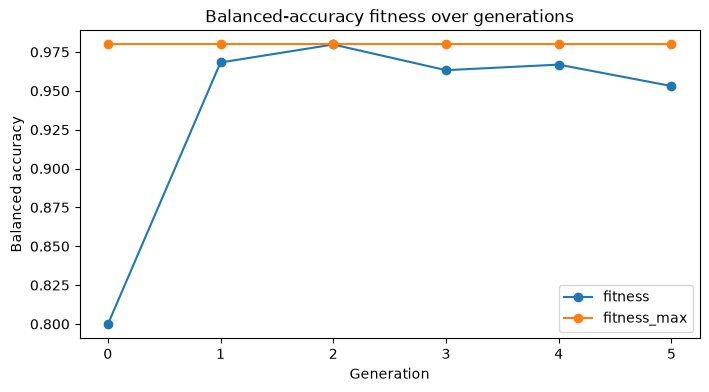

In [10]:
ax = history.plot(x="gen", y=["fitness", "fitness_max"], marker="o", figsize=(8, 4))
ax.set_title("Balanced-accuracy fitness over generations")
ax.set_xlabel("Generation")
ax.set_ylabel("Balanced accuracy")

## Change the Refit Metric

The same `cv_results_` can point to different candidate rankings. The example below shows the best row for each metric without rerunning the search. In a real workflow, choose `refit` before fitting based on the metric that best matches the product or scientific goal.

In [11]:
best_rows = []
for metric_name in ["accuracy", "balanced_accuracy", "f1_macro"]:
    row = results.sort_values(f"rank_test_{metric_name}").iloc[0]
    best_rows.append(
        {
            "metric": metric_name,
            "mean_test_score": row[f"mean_test_{metric_name}"],
            "rank": row[f"rank_test_{metric_name}"],
            "C": row["param_logistic__C"],
            "l1_ratio": row["param_logistic__l1_ratio"],
            "class_weight": row["param_logistic__class_weight"],
        }
    )

pd.DataFrame(best_rows)

,metric,mean_test_score,rank,C,l1_ratio,class_weight
0,accuracy,0.980952,1,1.0,0.0,None
1,balanced_accuracy,0.979798,1,1.0,0.0,None
2,f1_macro,0.980529,1,1.0,0.0,None


## Practical Notes

- With multi-metric scoring, set `refit` to the metric that should define the final model.
- `best_score_`, `best_params_`, and `best_estimator_` follow the `refit` metric, not every metric at once.
- Use `cv_results_` to inspect tradeoffs between metrics after fitting.
- Use `fit_stats_` and `history` to understand optimizer cost, duplicate candidates, diversity, stagnation, and convergence behavior.